# 사업보고서의 ESG 언어는 무엇을 측정하는가
### 한국 DART 텍스트 점수의 규모 편향과 표현 의존성 — 최종 제출 분석 노트북

**비정형데이터분석 · 2조** · 이승준 · 문상현 · 장석훈 · 정연진

> **한 줄 질문**: 사업보고서에 적힌 ESG 텍스트를 점수화하면, 그 점수는 실제 ESG 수준을 재는가, 아니면 기업 규모·공시 역량을 재는가?

**연구질문 (논문형 보고서와 동일)**
- **RQ1** — 사업보고서 ESG 텍스트 점수는 KCGS 등급과 연관되는가? (통제 전)
- **RQ2** — 기업 규모·공시 분량을 통제한 뒤에도 텍스트의 추가 설명력이 남는가?
- **RQ3** — 결론이 텍스트를 *어떻게 측정했는지*(표현 방식)에 의존하는가?

**구성 (12절 · 논문 흐름)**

| 절 | 내용 | 실행 방식 | 연결 |
|---|---|---|---|
| 0 | 환경 설정 · 분석 패널 로드 | 라이브 | — |
| 1 | 데이터 수집 (DART lineage) | 코드 + 로그 로드 | Data |
| 2 | 데이터 탐색 (EDA · Table 1) | **라이브** | Data |
| 3 | 전처리 (II·IV·VI · Kiwi) | 코드 + 산출물 로드 | Method |
| 4 | Feature — 4가지 텍스트 표현(2×2) | 코드 + 점수 로드 | Method |
| 5 | **확장사전 구축** (θ 스윕·후보검토·필터) | 산출물 로드 | Method |
| 6 | 측정 타당성 (Spearman · Mann-Whitney) | **라이브** | RQ1 |
| 7 | 회귀 (모델선택·단계통제·생존 매트릭스) | **라이브(엔진)** | RQ1·RQ2·RQ3 |
| 8 | 종합 (위계 R²·분량통념·표현수렴·약신호) | 검증 엔진 산출물 | RQ2·RQ3 |
| 9 | 알파(α) — 왜 지배구조(G)만 남았나 | 4가설 검증 | 심화 |
| 10 | 부록 강건성 (LMG·다중검정·금융제외·숫자밀도) | 검증 엔진 산출물 | 강건성 |
| 11 | 한계 · 결론 | 서술 | Discussion |
| 12 | 재현 · 제출 점검 | 라이브 | — |

**재현·실행 안내**
- 무거운 단계(DART API 수집 · Kiwi 전처리 · dense KURE-v1 인코딩 · fastText θ 스윕)는 **1회 수행한 산출물(CSV/PNG)을 로드**하고 생성 코드는 본문에 *함수 정의/엔진 호출* 형태로 둔다. 가벼운 분석(절 6·7과 절 2)은 검증된 엔진으로 **이 노트북에서 재실행**된다 → 로컬 CPU로 위→아래 완주(dense·fastText는 CSV 로드라 GPU 불필요).
- **단위/키**: `doc_id = {stock_code 6자리}_{fiscal_year}` (회사명 단독 merge 금지). **timing**: `esg_year = fiscal_year + 1`.
- **API key**: 환경변수 `DART_API_KEY`(.env)에서만 로드 — **코드·노트북·출력 어디에도 키 값을 쓰지 않는다.**
- **해석 원칙**: 연관/예측(인과 아님) · "유의 ≠ 중요"(효과크기·CI 병기) · 공시 강도 ≠ 실제 성과(cheap-talk) · 결론은 KCGS 단일 기준의 잠정 결론.

> 제출물 ②(이 노트북)는 제출물 ①(`ESG_최종보고서.docx`)의 근거 코드다. 본문의 표/그림은 보고서의 Table 1~4·부록과 대응한다.


## 0. 환경 설정 · 분석 패널 로드

In [1]:
import sys, os, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

ROOT = "/Users/home1/esg-dart-project"
sys.path.insert(0, ROOT + "/analysis")

# 검증된 종합 엔진(개별 트랙 재실행·재인코딩 없음). committed 05b 수치를 1e-6 이내 복원하는 엔진.
from synth_lib import (load_synthesis, fit_ordered, fit_ols, fit_logit, partial_spearman,
                       sig_stars, zscore, REPRS, TEXT_COLS, GRADE_COLS, INTEG_GRADE, ALL_DIMS,
                       LEN_Z, SIZE_Z, CTRL_FULL, SECTOR_DUMMIES, YEAR_DUMMIES, GRADE_MAP, DP, FIG)
from scipy.stats import spearmanr, mannwhitneyu
from IPython.display import Image, display

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

def show_fig(name): display(Image(filename=f"{FIG}/{name}.png"))
def show_tbl(name, n=None):
    df = pd.read_csv(f"{DP}/{name}.csv")
    display(df if n is None else df.head(n)); return df

# 3트랙 1:1 병합 분석 패널(381×50: 12 텍스트점수 + 등급 + 통제 + 더미 + z)
m = load_synthesis()
assert len(m) == 381 and m[TEXT_COLS].isna().sum().sum() == 0 and m["doc_id"].nunique() == 381
print("분석 패널 로드:", m.shape, "| 381 기업-연도 · 텍스트 결측 0 · doc_id 유일")
print("GRADE_MAP:", GRADE_MAP)

분석 패널 로드: (381, 50) | 381 기업-연도 · 텍스트 결측 0 · doc_id 유일
GRADE_MAP: {'S': 6, 'A+': 5, 'A': 4, 'B+': 3, 'B': 2, 'C': 1, 'D': 0}


## 1. 데이터 수집 (DART lineage)

**OpenDART API로 127개 기업의 2022·2023·2024 회계연도 사업보고서를 수집했다.** *(Data — RQ 공통 표본)*

- **표본**: 최대 127사 × 3개 회계연도 = 381 기업-연도. 수업 제공 표본이며 KCGS 전체의 대표표본이 아닌 pilot panel.
- **lineage 키**: `stock_code`(6자리) → `corp_code`(8자리, CORPCODE.xml) → 사업보고서 `rcept_no`(접수번호) → `fiscal_year`. 회사명만으로 merge하거나 접수번호가 다른 보고서를 섞지 않는다.
- **결측 처리**: 수집·추출 실패 행은 **가짜 0으로 채우지 않고** 사유를 기록(`dart_collection_status.csv`). 최종 분석 패널은 텍스트·등급이 모두 있는 행으로 구성(결측 0).
- **API key**: 환경변수 `DART_API_KEY`(.env)에서만 로드 — 아래 코드·노트북 어디에도 키 값이 없다.

In [2]:
# ── 수집 코드 (notebooks/01_데이터수집.ipynb 에서 1회 수행) — 함수 정의만, API 호출 없음 ──
import io, zipfile, requests
import xml.etree.ElementTree as ET
from dataclasses import dataclass

API_KEY = os.environ.get("DART_API_KEY", "")          # .env 로드, 코드에 키 값 없음
OPENDART_BASE = "https://opendart.fss.or.kr/api"

def build_stock_to_corp_map(corpcode_xml=ROOT + "/data/raw/CORPCODE.xml") -> dict:
    """OpenDART CORPCODE.xml → {stock_code(6자리): corp_code(8자리)} 매핑."""
    root = ET.parse(corpcode_xml).getroot()
    out = {}
    for el in root.iter("list"):
        sc = (el.findtext("stock_code") or "").strip()
        cc = (el.findtext("corp_code") or "").strip()
        if sc and sc != " " and cc:
            out[sc.zfill(6)] = cc
    return out

@dataclass
class ReportSelection:                                # 접수번호로 보고서 1건을 특정
    report_nm: str; rcept_no: str; rcept_dt: str
    corp_code: str; stock_code: str; fiscal_year: int

def fetch_business_report_list(corp_code: str, fiscal_year: int) -> dict:
    """정기공시 목록 조회(list.json) → 해당 회계연도 사업보고서 rcept_no 선택."""
    params = {"crtfc_key": API_KEY, "corp_code": corp_code,
              "bgn_de": f"{fiscal_year+1}0101", "end_de": f"{fiscal_year+1}1231",
              "pblntf_ty": "A", "page_count": 100}                  # A = 정기공시
    return requests.get(f"{OPENDART_BASE}/list.json", params=params, timeout=30).json()

# 핵심 섹션만 사용 (왜? — ESG 서술이 집중되는 본문)
TARGET_SECTIONS = ["II. 사업의 내용",
                   "IV. 이사의 경영진단 및 분석의견",
                   "VI. 이사회 등 회사의 기관에 관한 사항"]
print("수집 함수 정의 완료 (실제 호출은 .env의 DART_API_KEY 필요). 산출물은 아래에서 로드.")

수집 함수 정의 완료 (실제 호출은 .env의 DART_API_KEY 필요). 산출물은 아래에서 로드.


In [3]:
# 수집 lineage 로그 (수집여부·실패사유)
status = pd.read_csv(f"{ROOT}/data/processed/dart_collection_status.csv")
print("dart_collection_status.csv:", status.shape, "| 수집여부:", status["수집여부"].value_counts().to_dict())
print("최대 firm-year(127사×3년) =", 127*3, " | 분석 패널(텍스트·등급 결측 0) =", len(m))
print("timing: esg_year = fiscal_year + 1  (KCGS 평가연도 t ↔ 직전 회계연도 t-1 사업보고서)")
display(status.head(3))

dart_collection_status.csv: (381, 4) | 수집여부: {True: 381}
최대 firm-year(127사×3년) = 381  | 분석 패널(텍스트·등급 결측 0) = 381
timing: esg_year = fiscal_year + 1  (KCGS 평가연도 t ↔ 직전 회계연도 t-1 사업보고서)


,회사이름,esg_year,수집여부,실패사유
0,삼성전자,2023,True,NaN
1,삼성전자,2024,True,NaN
2,삼성전자,2025,True,NaN


## 2. 데이터 탐색 (EDA) — Table 1 등급 분포

**종속변수인 KCGS 등급의 분포를 먼저 본다.** 통합·E·S·G 등급은 모두 D(0)~A+(5) 서열변수다(GRADE_MAP). *(Data)*

- 통합 평균 ≈ 2.6, **A 이상(A+·A) 비중 ≈ 40%**. 차원별로 **S가 가장 높고(61%) G가 가장 낮으며(27%) 분산이 크다** — G는 변별력이 큰 차원(절 7·9의 복선).
- 핵심 섹션 II·IV·VI의 길이는 등급과 함께 증가하는 경향이 있으나, **이는 규모 매개임을 절 8에서 보인다**("긴 보고서=좋은 ESG" 통념 해체).
- 표본은 8개 업종으로 구성(업종 분포는 절 10 부록).

In [4]:
# Table 1 — KCGS 등급 분포 (N=381 기업-연도). 등급은 0=D … 5=A+ (S=6은 본 표본에 없음)
def grade_profile(col):
    s = m[col].dropna().astype(float)
    return {"N": int(s.size), "평균(0-5)": round(float(s.mean()), 2), "표준편차": round(float(s.std()), 2),
            "A이상(A+·A) %": round(100 * float((s >= 4).mean()), 1)}
tab1 = pd.DataFrame({"통합ESG": grade_profile(INTEG_GRADE), "E": grade_profile("e_grade"),
                     "S": grade_profile("s_grade"), "G": grade_profile("g_grade")}).T
print("Table 1. KCGS 등급 분포 (N=381)")
display(tab1)
order = ["S", "A+", "A", "B+", "B", "C", "D"]
print("통합등급 라벨 분포:", m["esg_grade"].value_counts().reindex(order).dropna().astype(int).to_dict())
print("연도별 표본:", m["fiscal_year"].value_counts().sort_index().to_dict(),
      "| 업종 수:", m["sector"].nunique())

Table 1. KCGS 등급 분포 (N=381)


,N,평균(0-5),표준편차,A이상(A+·A) %
통합ESG,381.000,2.600,1.620,39.900
E,381.000,2.820,1.580,45.100
S,381.000,3.230,1.900,61.200
G,381.000,2.340,1.520,27.000


통합등급 라벨 분포: {'A+': 29, 'A': 123, 'B+': 76, 'B': 36, 'C': 53, 'D': 64}
연도별 표본: {2022: 127, 2023: 127, 2024: 127} | 업종 수: 8


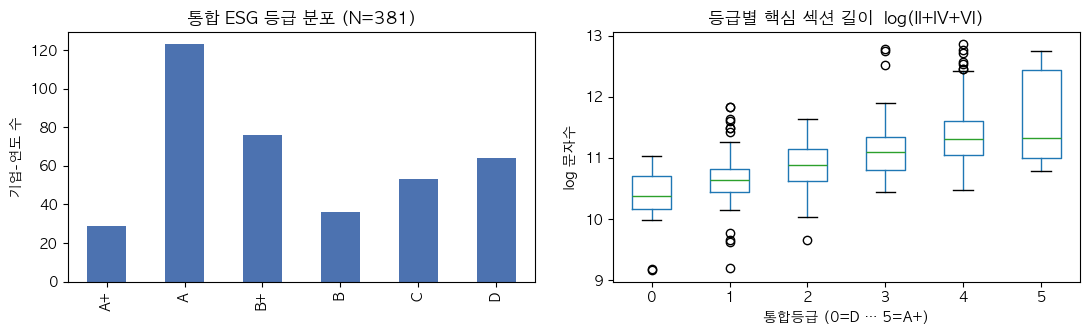

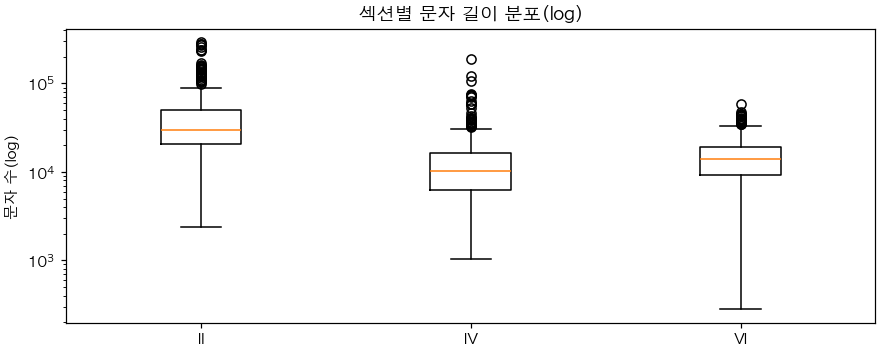

In [5]:
# 등급 분포(막대) + 등급별 핵심 섹션 길이(박스) — 라이브 그림
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"; plt.rcParams["axes.unicode_minus"] = False
try:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    m["esg_grade"].value_counts().reindex(order).dropna().plot.bar(ax=ax[0], color="#4C72B0")
    ax[0].set_title("통합 ESG 등급 분포 (N=381)"); ax[0].set_ylabel("기업-연도 수"); ax[0].set_xlabel("")
    m.boxplot(column="log_core_doc_len", by="esg_grade_num", ax=ax[1], grid=False)
    ax[1].set_title("등급별 핵심 섹션 길이  log(II+IV+VI)")
    ax[1].set_xlabel("통합등급 (0=D … 5=A+)"); ax[1].set_ylabel("log 문자수")
    fig.suptitle(""); plt.tight_layout(); plt.show()
except Exception as e:
    print("라이브 그림 생략 → 섹션 길이 그림 대체:", e)
# 섹션별(II·IV·VI) 길이 분포 (전처리 단계 산출 그림)
show_fig("07_step2_section_len")

## 3. 전처리 (II·IV·VI · Kiwi 형태소)

**핵심 섹션 II·IV·VI를 합쳐 `text_raw`를 만들고, Kiwi 형태소 분석으로 토큰화했다.** *(Method)*

- **섹션 선택 이유**: II(사업의 내용)·IV(MD&A)·VI(이사회 등 기관)는 환경·사회·지배구조 서술이 집중되는 본문이다(표·재무제표 위주 섹션 제외).
- **Kiwi는 `text_raw`(원문)에 적용**: 원문의 공백·문장 경계가 남아 단어 분리가 자연스럽다(`text_clean`은 경계가 약함).
- **토큰 필터**: 명사(N*)·동사/형용사(V*)·영문(SL)만 유지, 불용어(`stopwords_ko_esg.txt`)·길이 1 이하 제거 → 최종 토큰열 `kiwi_text`.
- 길이 통제변수 = `log(len_II + len_IV + len_VI)` (핵심 섹션 문자수).

In [6]:
# ── 전처리 코드 (notebooks/03_데이터전처리.ipynb 에서 1회 수행) ──
def tokenize_with_kiwi(text: str) -> list[str]:
    from kiwipiepy import Kiwi                       # 함수 내부 import(무거운 의존성 지연)
    kiwi = Kiwi()
    return [f"{t.form}/{t.tag}" for t in kiwi.tokenize(text)]

TFIDF_POS_PREFIXES = ("N", "V")                       # 명사·동사/형용사 계열
TFIDF_POS_TAGS = {"SL"}                               # 영문 단어
# tokens → 소문자·정규화 → 길이1 이하 제거 → 불용어 제거 → N/V/SL 만 → 공백조인 = kiwi_text

# 산출물 로드 (381×5: 회사이름·esg_year·raw_text·clean_text·kiwi_text)
pre = pd.read_csv(f"{ROOT}/data/processed/dart_preprocessed.csv")
seclen = pd.read_csv(f"{ROOT}/data/processed/dart_section_lengths.csv")
print("dart_preprocessed:", pre.shape, "| 컬럼:", list(pre.columns))
print("kiwi_text 예시:", repr(pre["kiwi_text"].iloc[0][:90]))
print("dart_section_lengths:", seclen.shape, "→ 길이통제 = log(len_II+len_IV+len_VI)")

dart_preprocessed: (381, 5) | 컬럼: ['회사이름', 'esg_year', 'raw_text', 'clean_text', 'kiwi_text']
kiwi_text 예시: '개요 일반 지배 기업 실체 재화 용역 근거 구분 정보 내부 목적 활용 제약 의료 기기 제조 판매업 기타 금융업 영위 기타 금융업 중요 관점 비중 지배 개황 구분 '
dart_section_lengths: (381, 11) → 길이통제 = log(len_II+len_IV+len_VI)


## 4. Feature 생성 — 4가지 텍스트 표현 (2×2)

**같은 보고서·같은 전처리 위에서 차원별(E/S/G) 점수를 네 방식으로 만들었다.** *(Method — Table 2)* 단어를 세는 표현은 *"감사위원회를 설치했다"* 와 *"설치하지 않았다"* 를 구별하지 못하므로, 의미를 보는 표현도 함께 둔다.

| | 단어 기반 | 의미 기반 |
|---|---|---|
| **비지도** | ① seed 사전 TF-IDF · ② fastText 확장 사전 TF-IDF | ③ dense cosine |
| **지도(등급 학습)** | — | ③ dense supervised probe |

- **① seed TF-IDF**: 과제 제공 seed 30개(E/S/G×10)의 TF-IDF 가중 합산(`min_df=2, max_df=0.95, L2`). 측정 대상 = "사업보고서에 ESG seed 표현이 얼마나 두드러지는가"(공시 강도, *성과 아님*).
- **② fastText 확장**: seed를 fastText 최근접으로 의미 확장 + LLM 필터(구축 과정은 **절 5**). 재현율↑·차원 특정성↓ 가능.
- **③ dense(KURE-v1)**: 문장 임베딩 + 이방성 제거(ABTT 화이트닝) + 하위차원 앵커 + 길이강건 풀링 → 비지도 cosine. 별도로 등급을 학습한 supervised probe(기업 단위 OOF, 낙관 편의 인지).
- **cheap-talk 주의**: 단어가 많이/길게 등장하는 것과 실제 성과는 구분해야 한다(아래 통제 회귀의 핵심).

In [7]:
# ── Feature ① seed TF-IDF: TF-IDF 행렬 구성 (notebooks/05b 설정 재현) ──
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(tokenizer=str.split, token_pattern=None, min_df=2, max_df=0.95, norm="l2")
X = vec.fit_transform(pre["kiwi_text"].fillna(""))
ok = "✓ 재현" if X.shape[1] == 40101 else "(주의)"
print(f"TF-IDF 행렬: docs={X.shape[0]} · vocab={X.shape[1]}  (기록값 vocab=40,101 {ok})")

seed = pd.read_csv(f"{ROOT}/data/raw/seed_dictionary.csv")
print("seed dictionary:", seed.shape[0], "개 term (E/S/G × 10):")
display(seed.groupby("dimension")["seed_term"].apply(lambda s: " · ".join(s)).to_frame("seed_terms"))
print("※ seed 구문 매칭(Kiwi tokenize_seed_phrase)은 05b 수행 → 점수는 05_tfidf_seed_features.parquet 로드(아래 m).")

TF-IDF 행렬: docs=381 · vocab=40101  (기록값 vocab=40,101 ✓ 재현)
seed dictionary: 30 개 term (E/S/G × 10):


,seed_terms
dimension,
E,탄소 · 온실가스 · 탄소중립 · 넷제로 · 재생에너지 · 에너지 · 전력 · 폐기...
G,이사회 · 사외이사 · 감사위원회 · 독립성 · 윤리 · 준법 · 컴플라이언스 · ...
S,안전 · 산업재해 · 중대재해 · 임직원 · 노동 · 인권 · 교육훈련 · 협력사 ...


※ seed 구문 매칭(Kiwi tokenize_seed_phrase)은 05b 수행 → 점수는 05_tfidf_seed_features.parquet 로드(아래 m).


In [8]:
# 4표현 × E/S/G = 12개 텍스트 점수 (분석 패널 m 에 병합 완료)
print("표현별 차원 점수 컬럼:")
for k, v in REPRS.items():
    print(f"  {v['label']:18s} → {v['cols']}")
display(m[TEXT_COLS].describe().T[["mean", "std", "min", "max"]].round(3))

표현별 차원 점수 컬럼:
  ① seed TF-IDF      → ['tfidf_E', 'tfidf_S', 'tfidf_G']
  ② fastText 확장      → ['expanded_tfidf_E', 'expanded_tfidf_S', 'expanded_tfidf_G']
  ③ dense cosine     → ['E_cos', 'S_cos', 'G_cos']
  ③ dense supervised → ['E_sup', 'S_sup', 'G_sup']


,mean,std,min,max
tfidf_E,0.096,0.094,0.000,0.495
tfidf_S,0.054,0.039,0.000,0.269
tfidf_G,0.028,0.029,0.000,0.219
expanded_tfidf_E,0.219,0.230,0.000,1.073
expanded_tfidf_S,0.143,0.091,0.007,0.522
expanded_tfidf_G,0.205,0.117,0.039,0.688
E_cos,0.238,0.086,0.108,0.468
S_cos,0.188,0.068,0.097,0.560
G_cos,0.238,0.065,0.112,0.586
E_sup,2.867,1.073,-0.028,5.107


## 5. 확장사전 구축 — θ 스윕 · 후보 검토 · 필터

**②fastText 확장 사전이 어떻게 만들어졌는지를 보인다.** *(Method — 루브릭 요구 항목)* seed 10개씩에서 출발해 임베딩으로 후보를 넓히고, **팀이 직접 읽고 LLM 보조로 회사명·보일러플레이트·무관어를 걸러낸** 사전이다. (fastText 재학습 없이 1회 산출물을 로드 — 생성 코드는 `04_피처엔지니어링.ipynb`·`scripts/llm_filter_candidates.py`.)

절차: ① seed → fastText 최근접 후보(차원별) → ② **θ(코사인 임계) 스윕**으로 후보 수·노이즈 비율 관찰 → ③ 후보를 **직접 검토**(`llm_keep`/사유) → ④ 회사명·의무 보일러 제거 → ⑤ 최종 확장사전. **θ를 높이면 정밀도↑·재현율↓**, 낮추면 그 반대 — 차원별 신호·노이즈 균형점을 택했다.

In [9]:
# (1) seed → fastText 최근접 후보 (검토본): candidate·similarity·llm_keep·사유
FE = f"{DP}/feature_engineering"
cand = pd.read_csv(f"{FE}/fasttext_seed_candidates_reviewed.csv")
print("fastText 후보(검토본):", cand.shape, "| 컬럼:", list(cand.columns))
print("LLM 채택률:", round(100*cand["llm_keep"].mean(), 1), "% (회사명·보일러·무관어는 탈락)")
display(cand.loc[cand["llm_keep"] == True, ["dimension","seed_term","rank_within_seed","candidate","similarity","llm_reason"]].head(8))
display(cand.loc[cand["llm_keep"] == False, ["dimension","seed_term","candidate","similarity","llm_reason"]].head(4))

fastText 후보(검토본): (13137, 8) | 컬럼: ['dimension', 'seed_term', 'rank_within_seed', 'candidate', 'similarity', 'source_query_term', 'llm_keep', 'llm_reason']
LLM 채택률: 10.8 % (회사명·보일러·무관어는 탈락)


,dimension,seed_term,rank_within_seed,candidate,similarity,llm_reason
0,E,탄소,1,로드맵,0.696,탄소감축 목표 달성을 위한 실행 계획의 일반 용어
1,E,탄소,2,배출량,0.688,탄소배출량 측정의 핵심 지표
2,E,탄소,3,감축,0.686,"탄소감축의 동의어, 기후변화 대응 활동"
3,E,탄소,4,온실가스인벤토리,0.684,탄소 포함 온실가스 관리의 표준 제도
4,E,탄소,5,기후,0.670,기후변화 완화 관련 ESG 환경 차원
5,E,탄소,6,목표량,0.661,탄소감축 목표 설정의 핵심 요소
7,E,탄소,8,허용량,0.650,탄소배출권 관련 규제 기준값
8,E,탄소,9,저감,0.647,탄소감축의 동의어


,dimension,seed_term,candidate,similarity,llm_reason
6,E,탄소,넷제로은행연합,0.657,"특정 기구명, 일반 사전어 아님"
9,E,탄소,동참,0.637,ESG 무관 일반 동작 동사
10,E,탄소,녹생,0.635,"형태소 조각, 명사로 성립하지 않는 어근"
11,E,탄소,환경재,0.634,탄소와 직접 관련 없는 경제학 개념


θ 스윕 요약 (θ↑ → 후보↓·정밀도↑):


,theta,unique_candidates,top100_noise_count,top100_noise_ratio,E_terms,S_terms,G_terms
0,0.450,7108,40,0.400,2196,2202,2710
1,0.500,6455,40,0.400,1949,1893,2613
2,0.550,5267,40,0.400,1537,1389,2341
3,0.600,3502,40,0.400,875,771,1856
4,0.650,2256,40,0.400,511,265,1480
5,0.700,1190,40,0.400,153,77,960
6,0.750,578,40,0.400,81,32,465


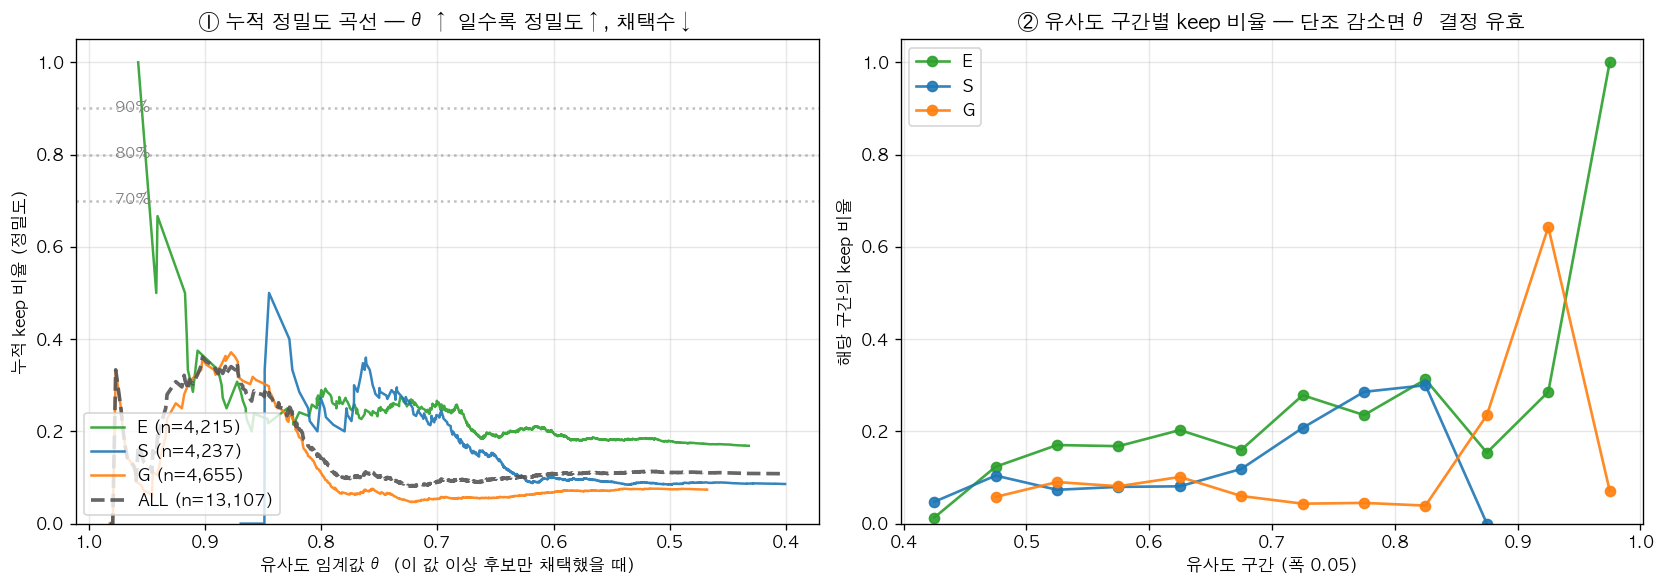

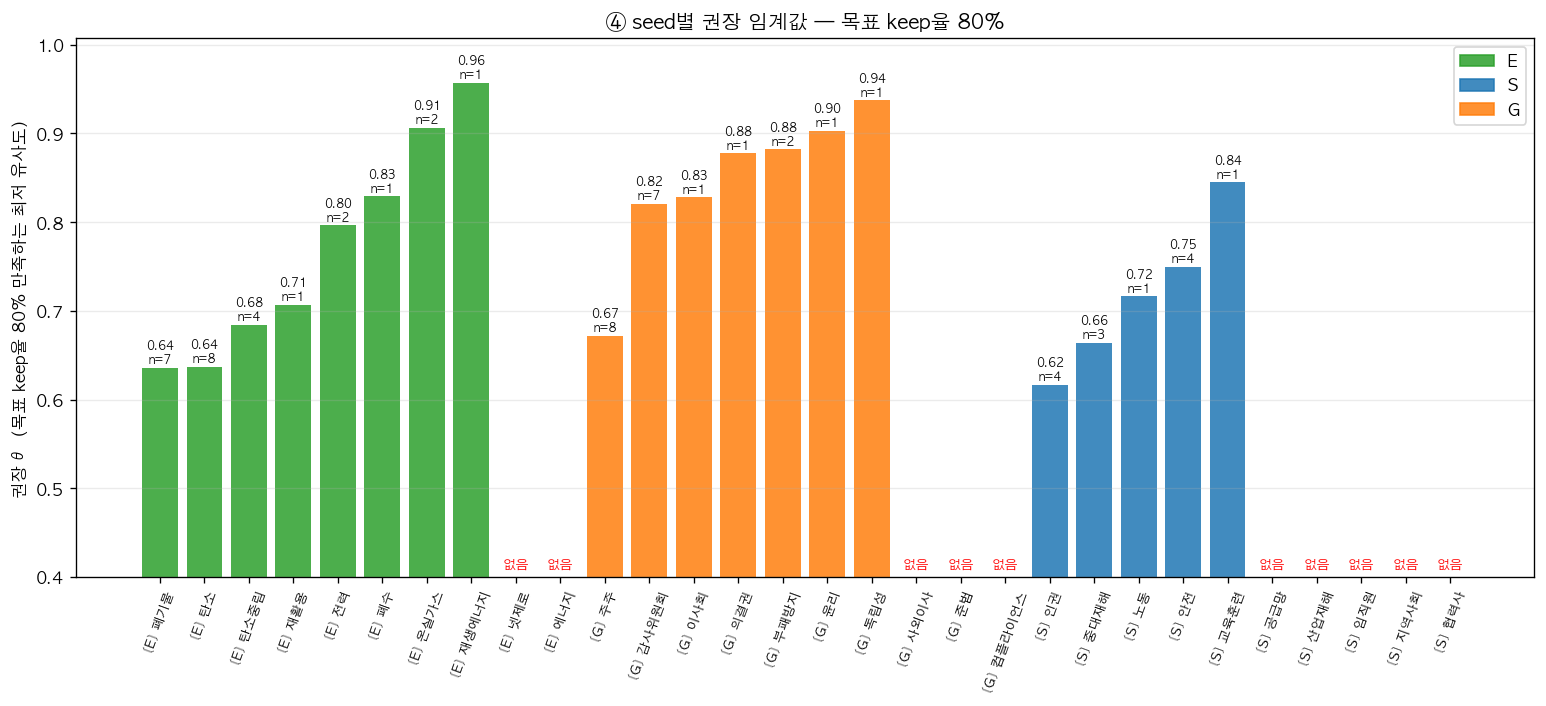

In [10]:
# (2) θ 스윕 — θ별 후보 수·top100 노이즈 비율·차원별 단어 수 (정밀도-재현율 절충)
thr = pd.read_csv(f"{FE}/fasttext_threshold_summary.csv")
print("θ 스윕 요약 (θ↑ → 후보↓·정밀도↑):")
display(thr)
show_fig("00_threshold_precision_curves"); show_fig("00_per_seed_recommended_theta")

In [11]:
# (3) 최종 확장사전 — seed 30개 → 확장어 (회사명·보일러 제거 후)
rep = pd.read_csv(f"{DP}/05c_expanded_tfidf_dictionary_report.csv")
view = rep[["dimension","seed_term","original_candidate_count","fasttext_candidate_count","expanded_candidate_count","candidate_terms"]]
print("최종 확장사전(seed→확장어):", rep.shape, "| 차원별 확장어 합:",
      rep.groupby("dimension")["expanded_candidate_count"].sum().to_dict())
display(view.head(10))
print("→ ②확장 점수(expanded_tfidf_*)는 이 사전으로 05c에서 산출. 효과는 절 7·8에서 평가(확장은 차원특정성↓).")

최종 확장사전(seed→확장어): (30, 12) | 차원별 확장어 합: {'E': 281, 'G': 248, 'S': 193}


,dimension,seed_term,original_candidate_count,fasttext_candidate_count,expanded_candidate_count,candidate_terms
0,E,탄소,1,18,19,"['cdp', 'sbti', '감축', '개질수소', '기타간접배출원', '기후',..."
1,E,온실가스,2,11,13,"['ghg', 'scope', '감축', '기타간접배출원', '목표량', '배출',..."
2,E,탄소중립,3,23,26,"['cdp', 'sbti', '감축', '개질수소', '기타간접배출원', '기후',..."
3,E,넷제로,4,10,14,"['mitigation', 'ndc', 'net', 'netting', 'netze..."
4,E,재생에너지,6,31,37,"['certificate', 'certificates', 'certification..."
5,E,에너지,1,21,22,"['lng', 'mwh', '그린에너지', '기타간접배출원', '뉴에너지', '바이..."
6,E,전력,3,53,56,"['gwh', 'kwh', 'mwh', 'scope', 'toe', 'twh', '..."
7,E,폐기물,1,17,18,"['감량', '매립', '발생량', '보관장', '분리수거', '분진', '수거',..."
8,E,재활용,5,8,13,"['발생량', '분리수거', '선순환', '순환', '순환자원인증', '자원', '..."
9,E,폐수,3,60,63,"['ppm', 'toc', '광유류', '규조류', '농도', '누출', '다이옥신..."


→ ②확장 점수(expanded_tfidf_*)는 이 사전으로 05c에서 산출. 효과는 절 7·8에서 평가(확장은 차원특정성↓).


## 6. 측정 타당성 — Spearman 순위상관 + Mann-Whitney  〔라이브〕  · **RQ1**

**회귀 전에 각 feature가 KCGS 등급과 통계적으로 연관되는지 먼저 확인한다.** 등급은 서열변수이므로 Spearman 순위상관이 자연스럽다. "ρ가 0.10–0.20이면 유의해도 효과는 약함"을 함께 본다. → **RQ1의 1차 근거(통제 전 연관은 실재).**

In [12]:
# (a) seed TF-IDF × KCGS 등급 — raw Spearman 3×3 (통제 없음)
seed_cols = {"E": "tfidf_E", "S": "tfidf_S", "G": "tfidf_G"}
gcols = {"E": "e_grade", "S": "s_grade", "G": "g_grade"}
rho = pd.DataFrame(index=["tfidf_"+d for d in ALL_DIMS], columns=[d+"_grade" for d in ALL_DIMS], dtype=float)
for i, td in enumerate(ALL_DIMS):
    for j, gd in enumerate(ALL_DIMS):
        rho.iloc[i, j] = spearmanr(m[seed_cols[td]], m[gcols[gd]]).statistic
print("seed TF-IDF × 등급 raw Spearman 3×3 (대각=자기차원):")
display(rho.round(3))
print("raw 대각지배 3/3:", all(rho.iloc[i, i] == rho.iloc[i].max() for i in range(3)),
      " — 단, 비대각도 높음(공시 충실도 단일요인 신호) → 통제 회귀 필수")

seed TF-IDF × 등급 raw Spearman 3×3 (대각=자기차원):


,E_grade,S_grade,G_grade
tfidf_E,0.359,0.306,0.203
tfidf_S,0.358,0.385,0.353
tfidf_G,0.422,0.470,0.510


raw 대각지배 3/3: True  — 단, 비대각도 높음(공시 충실도 단일요인 신호) → 통제 회귀 필수


In [13]:
# (b) Mann-Whitney: A이상(high_esg) vs 그외 — tfidf_G 분포 차이
hi = m.loc[m["high_esg"] == 1, "tfidf_G"]; lo = m.loc[m["high_esg"] == 0, "tfidf_G"]
U, p = mannwhitneyu(hi, lo, alternative="two-sided")
print(f"Mann-Whitney tfidf_G (A이상 n={len(hi)} vs 그외 n={len(lo)}): U={U:.0f}, p={p:.2e}")
print(f"  median  A이상={hi.median():.3f}  vs  그외={lo.median():.3f}")

# (c) feature 판단 표 (자기차원 raw Spearman) — ipynb 가이드 형식
jud = []
for k, v in REPRS.items():
    for dim, col in zip(ALL_DIMS, v["cols"]):
        rr = spearmanr(m[col], m[gcols[dim]])
        verdict = ("뚜렷한 관계 없음" if rr.pvalue > 0.05 else
                   "양의 관계·약함" if rr.statistic < 0.30 else "양의 관계")
        jud.append({"feature": col, "grade": dim+"_grade",
                    "Spearman ρ": round(rr.statistic, 3), "p": round(rr.pvalue, 4), "판단": verdict})
display(pd.DataFrame(jud))

Mann-Whitney tfidf_G (A이상 n=152 vs 그외 n=229): U=26596, p=2.25e-18
  median  A이상=0.032  vs  그외=0.013


,feature,grade,Spearman ρ,p,판단
0,tfidf_E,E_grade,0.359,0.000,양의 관계
1,tfidf_S,S_grade,0.385,0.000,양의 관계
2,tfidf_G,G_grade,0.510,0.000,양의 관계
3,expanded_tfidf_E,E_grade,0.363,0.000,양의 관계
4,expanded_tfidf_S,S_grade,0.429,0.000,양의 관계
5,expanded_tfidf_G,G_grade,0.337,0.000,양의 관계
6,E_cos,E_grade,0.306,0.000,양의 관계
7,S_cos,S_grade,0.201,0.000,양의 관계·약함
8,G_cos,G_grade,-0.028,0.589,뚜렷한 관계 없음
9,E_sup,E_grade,0.548,0.000,양의 관계


In [14]:
# (d) 상위/하위 문장 직접 읽기 — feature 해석이 맞는지 확인 (tfidf_G 상·하위 기업)
ex = pd.read_csv(f"{DP}/08_h2_top_vs_bottom.csv")
print("tfidf_G 상위 vs 하위 기업 비교:", ex.shape, "| 컬럼:", list(ex.columns))
display(ex.head(8))

tfidf_G 상위 vs 하위 기업 비교: (4, 3) | 컬럼: ['metric', 'top10_mean', 'bot10_mean']


,metric,top10_mean,bot10_mean
0,DRIVER 밀도(/100문장),2.150,0.660
1,BOILER 밀도(/100문장),15.190,22.420
2,g_grade,3.500,1.400
3,문장 수(길이),383.600,198.900


## 7. 회귀분석 — 모델 선택 · 단계적 통제 · 생존 매트릭스  〔라이브〕  · **RQ1·RQ2·RQ3**

**ESG 등급은 D~A+의 서열변수이므로 순서형 로짓(ordered logit)을 주 모형으로 쓰고, 이진 로짓(A 이상)·OLS를 강건성 확인용으로 병행한다.**

- 텍스트 점수는 z-표준화(모집단 std), 표준오차는 기업 단위 군집화(같은 기업 3개 연도 의존성).
- **통제 순서**: 규모(log 자산) → 분량(log 핵심 문자수) → 업종(8더미, 기준 1차금속) → 연도(기준 2022)를 **먼저** 투입하고 텍스트를 마지막에 넣는다. 그래야 텍스트의 *추가* 설명력이 진짜인지 가려진다(규모가 1차 교란임을 절 8에서). → 완전통제 후 생존 차원 = **RQ2·RQ3의 핵심 표**.

In [15]:
# (a) 모델 선택 데모 — 같은 스펙을 세 모형으로
xs = ["tfidf_G_z", LEN_Z, SIZE_Z]
ro = fit_ordered(m, INTEG_GRADE, xs); rl = fit_logit(m, "high_esg", xs); rO = fit_ols(m, INTEG_GRADE, xs)
print("통합등급 ~ tfidf_G_z + 길이 + 규모  (모형 비교):")
print(f"  순서형 로짓 : tfidf_G_z={ro['params']['tfidf_G_z']:.3f} (p={ro['pvals']['tfidf_G_z']:.3f})  McFadden={ro['mcfadden']:.3f}")
print(f"  이진 로짓(A↑): tfidf_G_z={rl['params']['tfidf_G_z']:.3f} (p={rl['pvals']['tfidf_G_z']:.3f})  pseudoR²={rl['prsquared']:.3f}")
print(f"  OLS         : tfidf_G_z={rO['params']['tfidf_G_z']:.3f} (p={rO['pvals']['tfidf_G_z']:.3f})  R²={rO['r2']:.3f}")
print("→ 서열 보존 위해 순서형을 주 모형으로, 이진/OLS는 강건성 확인용.")

통합등급 ~ tfidf_G_z + 길이 + 규모  (모형 비교):
  순서형 로짓 : tfidf_G_z=0.491 (p=0.000)  McFadden=0.201
  이진 로짓(A↑): tfidf_G_z=0.615 (p=0.000)  pseudoR²=0.325
  OLS         : tfidf_G_z=0.355 (p=0.000)  R²=0.511
→ 서열 보존 위해 순서형을 주 모형으로, 이진/OLS는 강건성 확인용.


In [16]:
# (b) 엔진 신뢰성 — committed 05b 수치 복원 확인
r = fit_ordered(m, "g_grade", ["tfidf_G_z", LEN_Z, SIZE_Z] + SECTOR_DUMMIES + YEAR_DUMMIES)
print(f"seed-G 완전통제 계수 = {r['params']['tfidf_G_z']:.4f}  (기록 0.378),  p={r['pvals']['tfidf_G_z']:.4f}")
ri = fit_ordered(m, INTEG_GRADE, ["tfidf_E_z","tfidf_S_z","tfidf_G_z", LEN_Z, SIZE_Z] + SECTOR_DUMMIES + YEAR_DUMMIES)
print(f"통합: log_assets_z={ri['params'][SIZE_Z]:.3f} (기록 1.062)  >  tfidf_G_z={ri['params']['tfidf_G_z']:.3f} (기록 0.458)")
print("→ 규모(log 자산)가 텍스트보다 지배적. 엔진이 committed 값을 복원 → 4표현에 동일 적용 신뢰.")

seed-G 완전통제 계수 = 0.3780  (기록 0.378),  p=0.0034


통합: log_assets_z=1.062 (기록 1.062)  >  tfidf_G_z=0.458 (기록 0.458)
→ 규모(log 자산)가 텍스트보다 지배적. 엔진이 committed 값을 복원 → 4표현에 동일 적용 신뢰.


완전통제(길이·규모·업종·연도) 후 자기차원 계수 — '유의' 칸이 비면 통제 후 소멸:


차원,E,S,G
표현,,,
① seed TF-IDF,0.298,0.004,0.378
② fastText 확장,0.235,0.099,0.302
③ dense cosine,0.255,0.094,-0.058
③ dense supervised,0.157,0.550,0.121


차원,E,S,G
표현,,,
① seed TF-IDF,,,**
② fastText 확장,,,
③ dense cosine,,,
③ dense supervised,,*,


차원별 완전통제 후 생존 표현 수(4 중): {'E': 0, 'S': 1, 'G': 1} → ① seed=G · ③ supervised=S · 그 외 없음. 어느 차원도 과반(>2) 재현 안 됨.


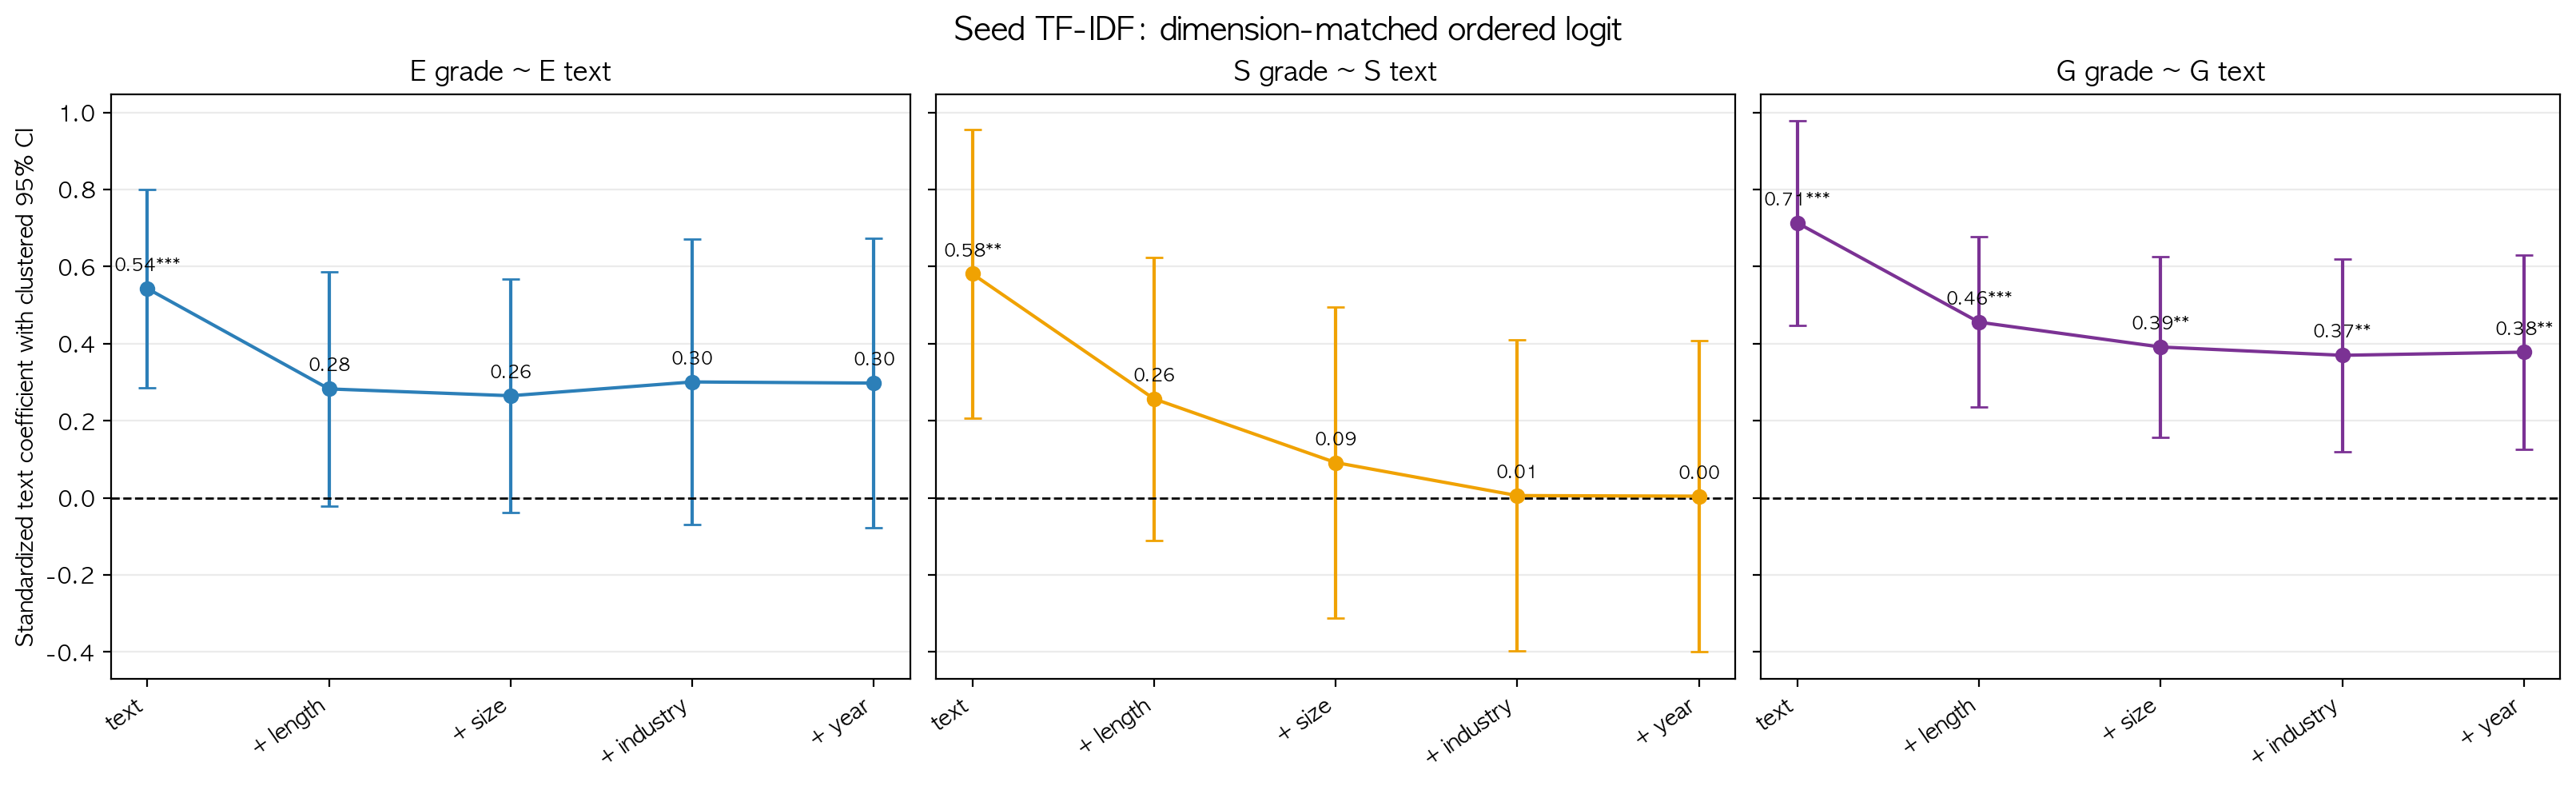

In [17]:
# (c) ★ 완전통제 후 자기차원 텍스트 계수 — 4표현 × E/S/G 라이브 재현 (= 보고서 Table 4)
rows = []
for k, v in REPRS.items():
    for dim, col in zip(ALL_DIMS, v["cols"]):
        rr = fit_ordered(m, GRADE_COLS[dim], [col+"_z"] + CTRL_FULL)
        b = rr["params"][col+"_z"]; p = rr["pvals"][col+"_z"]
        rows.append({"표현": v["label"], "차원": dim, "계수": round(b, 3), "p": round(p, 4), "유의": sig_stars(p)})
surv = pd.DataFrame(rows)
print("완전통제(길이·규모·업종·연도) 후 자기차원 계수 — '유의' 칸이 비면 통제 후 소멸:")
display(surv.pivot(index="표현", columns="차원", values="계수")[["E","S","G"]])
display(surv.pivot(index="표현", columns="차원", values="유의")[["E","S","G"]].fillna(""))
ms = surv.assign(생존=surv["p"] < 0.05).groupby("차원")["생존"].sum().reindex(ALL_DIMS)
print("차원별 완전통제 후 생존 표현 수(4 중):", ms.to_dict(),
      "→ ① seed=G · ③ supervised=S · 그 외 없음. 어느 차원도 과반(>2) 재현 안 됨.")
show_fig("05b_tfidf_seed_matched_ordered_logit_text_effects")

**해석.** ① 규모가 1차 예측자이고(절 8), 텍스트의 추가 설명력은 작다(**RQ2**). ② 완전통제 후 살아남는 차원이 **표현마다 다르다**(단어 기반은 G, 학습된 의미는 S, 나머지는 없음 — **RQ3**). 진짜 강한 차원 신호가 있었다면 표현을 바꿔도 같은 차원이 살아야 한다 — 그렇지 않으므로, 텍스트–등급 연관은 차원특정이 아니라 단일 "공시 충실도" 요인에 가깝다(절 8의 PC1 92%).

## 8. 종합 (synthesis) — 위계적 R² · 분량 통념 · 표현 간 수렴 · 약신호  · **RQ2·RQ3**

> 검증 엔진 `analysis/07d_synthesis.py`(+`synth_lib.py`)의 산출물(`07d_*.csv`/`.png`)을 정리한다. 단일 출처 서술 = `종합_기록.md`.

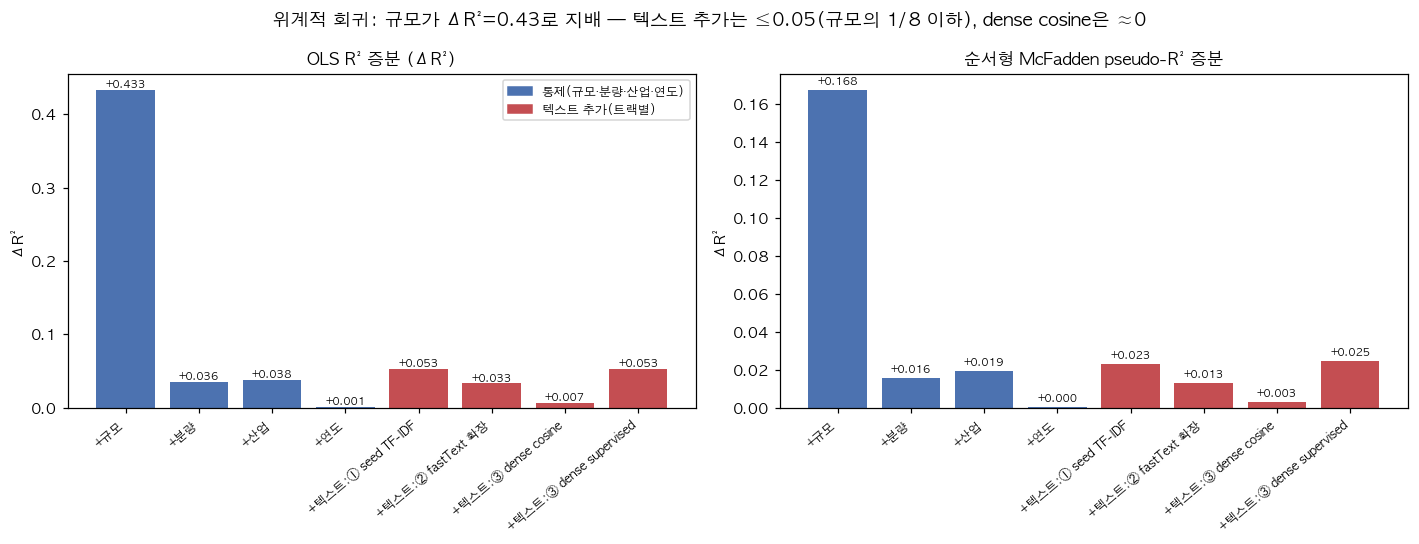

,block,kind,ols_r2,ols_dr2,mcfadden,mcf_dr2
0,+규모,통제,0.433,0.433,0.168,0.168
1,+분량,통제,0.469,0.036,0.183,0.016
2,+산업,통제,0.506,0.038,0.203,0.019
3,+연도,통제,0.507,0.001,0.203,0.000
4,+텍스트:① seed TF-IDF,텍스트,0.560,0.053,0.226,0.023
5,+텍스트:② fastText 확장,텍스트,0.540,0.033,0.216,0.013
6,+텍스트:③ dense cosine,텍스트,0.514,0.007,0.206,0.003
7,+텍스트:③ dense supervised,텍스트,0.560,0.053,0.227,0.025


In [18]:
# (1) 위계적 R² — 규모 한 변수가 통합등급 분산의 43%, 텍스트 증분은 ≤5.3%p  [RQ2]
show_fig("07d_a1_block_increments"); _ = show_tbl("07d_a1_hierarchical_r2")

규모(자산) 하나로 통합등급 분산의 **43%**(OLS R²)가 설명되고, 분량·산업·연도까지 더해 50.7%가 된다. 그 위에 **E·S·G 텍스트 3개를 통째로 더해도 증분은 0.7%p(dense cosine)~5.3%p(seed·supervised)** — 규모의 1/8 이하다. 어떤 표현을 써도 텍스트는 규모를 못 이긴다. **(RQ2: 통제 후 설명력은 작다.)**

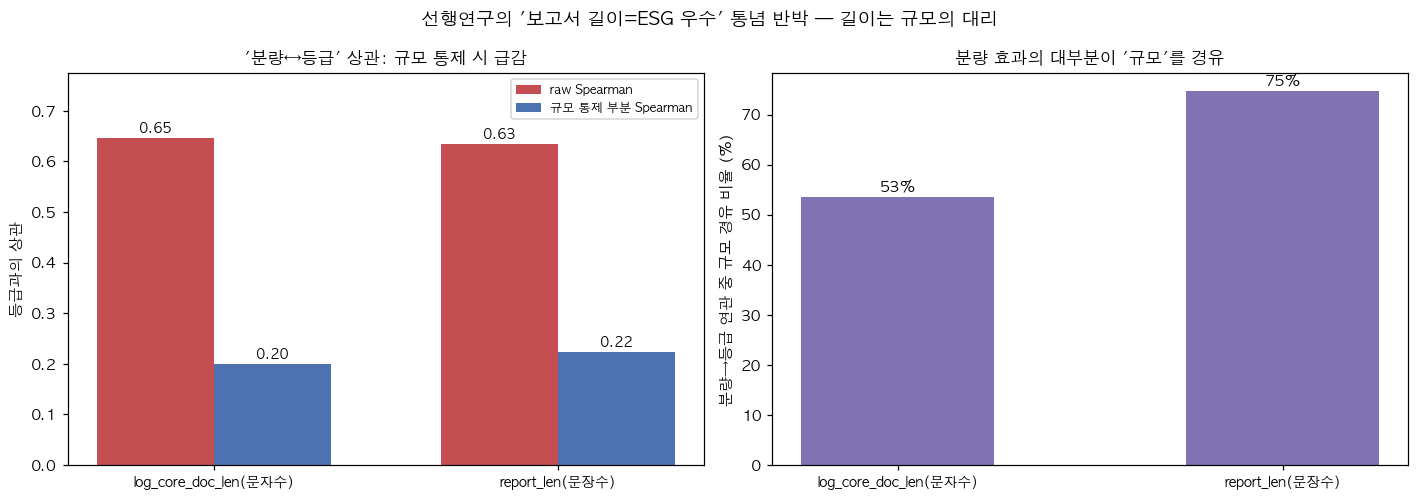

,length_def,spearman_raw,pearson_raw,partial_spearman_ctrl_size,drop,coef_total,coef_direct,pct_via_size
0,log_core_doc_len(문자수),0.646,0.622,0.200,0.446,1.009,0.470,0.534
1,report_len(문장수),0.634,0.492,0.224,0.410,0.798,0.203,0.746


In [19]:
# (2) "긴 보고서 = 좋은 등급" 통념(cheap-talk) — 규모 통제 시 급감  [RQ2]
show_fig("07d_a4_length_myth"); _ = show_tbl("07d_a4_length_myth")

분량–등급 단순상관은 0.65로 커 보이지만, **규모를 통제하면 부분상관 0.20으로 급감**한다(연관의 53~75%가 규모 경유). "긴 보고서=좋은 ESG"가 아니라 "큰 회사가 길게 쓰고 등급도 높다"이다.

seed TF-IDF 부분 3×3 Spearman (길이+규모 통제) — 약하지만 대각지배 3/3:


,E_grade,S_grade,G_grade
tfidf_E,0.198,0.129,-0.013
tfidf_S,0.023,0.095,0.056
tfidf_G,-0.049,0.082,0.173


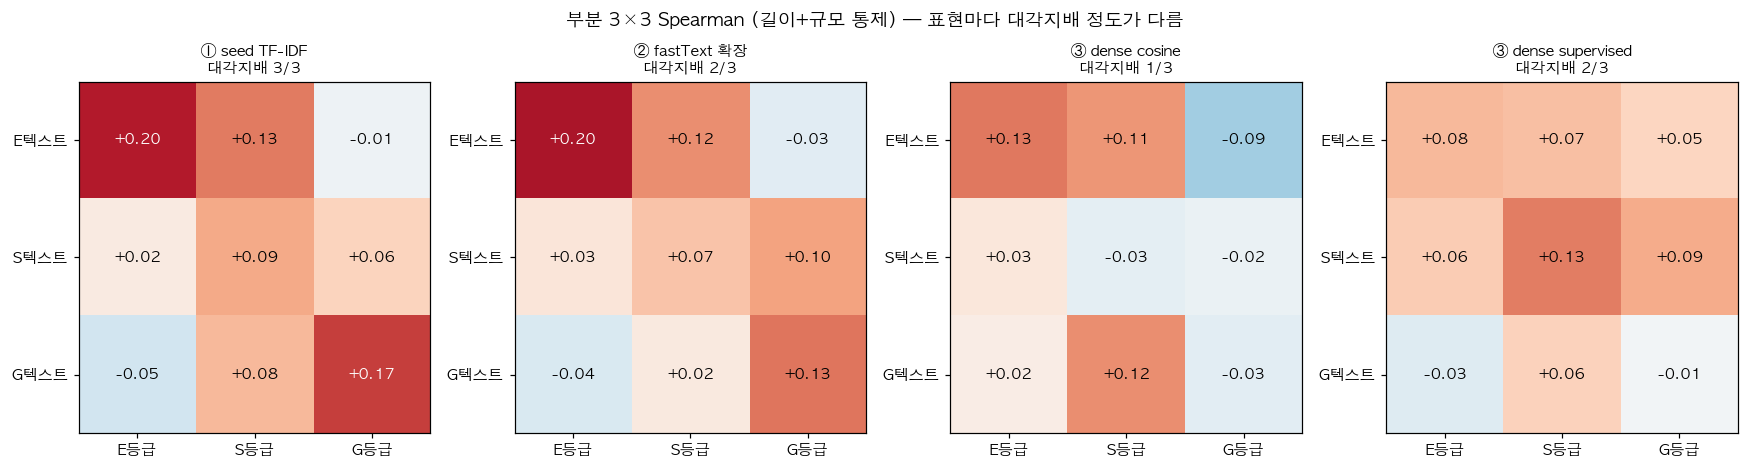

In [20]:
# (3) 부분 3×3 대각지배 (길이+규모 통제) — seed 라이브 + 4패널 종합
pp = pd.DataFrame(index=["tfidf_"+d for d in ALL_DIMS], columns=[d+"_grade" for d in ALL_DIMS], dtype=float)
for i, td in enumerate(ALL_DIMS):
    for j, gd in enumerate(ALL_DIMS):
        pp.iloc[i, j] = partial_spearman(m, seed_cols[td], gcols[gd], [LEN_Z, SIZE_Z])
print("seed TF-IDF 부분 3×3 Spearman (길이+규모 통제) — 약하지만 대각지배 3/3:")
display(pp.round(3))
show_fig("07d_a3_partial3x3_panels")

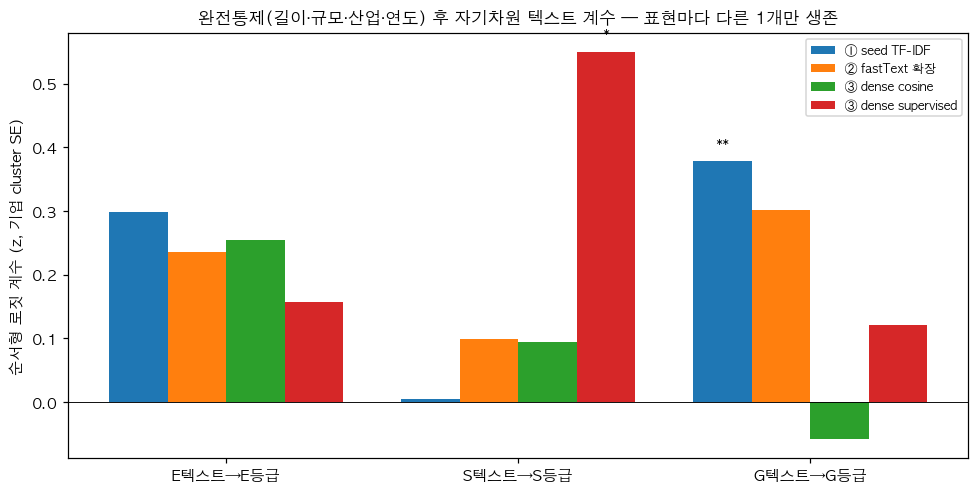

▶ 차원별 생존(표현) 수 — 어느 차원도 과반 재현 안 됨


,dim,n_repr,n_survive_p05,survivors,max_coef,min_p
0,E,4,0,(없음),0.298,0.117
1,S,4,1,③ dense supervised,0.550,0.013
2,G,4,1,① seed TF-IDF,0.378,0.003


▶ 트랙 간 같은차원 수렴(seed×dense cosine): E·S는 같은 회사, G는 −0.06(정반대)


,dim,repr_a,repr_b,col_a,col_b,spearman
0,E,seed_tfidf,expanded,tfidf_E,expanded_tfidf_E,0.956
1,E,seed_tfidf,dense_cos,tfidf_E,E_cos,0.448
2,E,seed_tfidf,dense_sup,tfidf_E,E_sup,0.260
3,E,expanded,dense_cos,expanded_tfidf_E,E_cos,0.457
4,E,expanded,dense_sup,expanded_tfidf_E,E_sup,0.256
5,E,dense_cos,dense_sup,E_cos,E_sup,0.320
6,S,seed_tfidf,expanded,tfidf_S,expanded_tfidf_S,0.770
7,S,seed_tfidf,dense_cos,tfidf_S,S_cos,0.295
8,S,seed_tfidf,dense_sup,tfidf_S,S_sup,0.499
9,S,expanded,dense_cos,expanded_tfidf_S,S_cos,0.328


In [21]:
# (4) 표현 간 수렴 + 생존 매트릭스 + 트랙간 G 수렴(정반대)  [RQ3]
show_fig("07d_a3_fullcontrol_bars")
print("▶ 차원별 생존(표현) 수 — 어느 차원도 과반 재현 안 됨"); _ = show_tbl("07d_a3_meta_survival")
print("▶ 트랙 간 같은차원 수렴(seed×dense cosine): E·S는 같은 회사, G는 −0.06(정반대)")
conv = show_tbl("07d_a3_convergence")

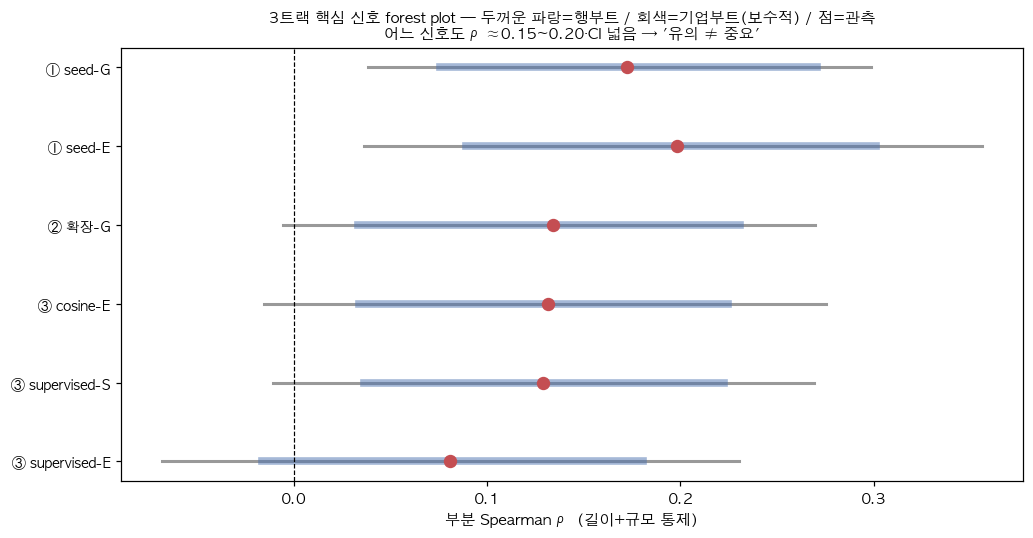

,signal,text_col,grade,obs_partial_rho,row_ci_lo,row_ci_hi,firm_ci_lo,firm_ci_hi,perm_p,firm_excl0,matched_coef,matched_p,matched_sig,matched_ci_lo,matched_ci_hi,effect,verdict
0,① seed-G,tfidf_G,g_grade,0.173,0.076,0.271,0.038,0.299,0.001,True,0.378,0.003,**,0.125,0.631,약,기업부트 0제외(견고)
1,① seed-E,tfidf_E,e_grade,0.198,0.089,0.301,0.036,0.356,0.000,True,0.298,0.121,NaN,-0.079,0.674,약,기업부트 0제외(견고)
2,② 확장-G,expanded_tfidf_G,g_grade,0.134,0.033,0.231,-0.005,0.270,0.011,False,0.302,0.086,NaN,-0.043,0.646,약,행부트 0제외·기업부트 0포함(경계)
3,③ cosine-E,E_cos,e_grade,0.132,0.034,0.225,-0.015,0.275,0.010,False,0.255,0.117,NaN,-0.064,0.573,약,행부트 0제외·기업부트 0포함(경계)
4,③ supervised-S,S_sup,s_grade,0.129,0.036,0.223,-0.011,0.269,0.014,False,0.550,0.013,*,0.116,0.984,약,행부트 0제외·기업부트 0포함(경계)
5,③ supervised-E,E_sup,e_grade,0.081,-0.017,0.180,-0.068,0.230,0.113,False,0.157,0.477,NaN,-0.276,0.590,약,0 포함(비유의)


In [22]:
# (5) 약신호의 정밀도 — 부트스트랩 CI·순열검정 통일 잣대 ("유의 ≠ 중요")
show_fig("07d_a6_forest"); _ = show_tbl("07d_a6_signal_ci")

In [23]:
# (6) E·S·G 점수가 한 요인으로 붕괴하는가 — 4표현 PC1 설명분산
from sklearn.decomposition import PCA
pc1 = {}
for k, v in REPRS.items():
    Z = ((m[v["cols"]] - m[v["cols"]].mean()) / m[v["cols"]].std(ddof=0)).values
    pc1[v["label"]] = round(float(PCA(n_components=3).fit(Z).explained_variance_ratio_[0]) * 100, 1)
print("표현별 E·S·G 점수의 제1주성분(PC1) 설명분산 % — 높을수록 '단일 공시충실도' 요인:")
print(pc1)
print("→ 특히 ③지도(supervised)에서 PC1=92%: E·S·G가 한 축으로 붕괴(차원 분리 실패). 비지도 표현은 48~55%.")

표현별 E·S·G 점수의 제1주성분(PC1) 설명분산 % — 높을수록 '단일 공시충실도' 요인:
{'① seed TF-IDF': 54.5, '② fastText 확장': 53.1, '③ dense cosine': 47.8, '③ dense supervised': 92.1}
→ 특히 ③지도(supervised)에서 PC1=92%: E·S·G가 한 축으로 붕괴(차원 분리 실패). 비지도 표현은 48~55%.


세 트랙의 "살아남은" 신호를 하나의 부분상관 잣대로 재면 어느 것도 강하지 않다(**ρ≈0.13~0.20**, CI 넓음). 가장 견고한 seed-G도 부분ρ 0.17, 보수적 기업부트 95% CI [0.04, 0.30]이다. **통계적 유의 ≠ 중요·정밀.** 또한 지도학습 표현에서 E·S·G 점수가 **PC1 한 축(92%)으로 붕괴** — 세 차원을 따로 재고 있다기보다 "공시 충실도" 단일 요인에 가깝다. **(RQ3: 결론이 표현에 의존.)**

## 9. 알파(α) — 왜 지배구조(G)만 남았나  〔팀 자체 설계 추가검증〕

**기본 과제(수집·전처리·feature·회귀) 외에, 팀이 스스로 설계한 추가 검증이다.** "완전통제 후 seed TF-IDF의 G만 강건 생존"이라는 발견의 *원인*을 4개 경쟁가설(H1 KCGS 구조 / H2 선택적 어휘 / H3 사전 품질 / H4 dense 실패)로 분해했다. 순위 **H2 > H1 > H3 > H4**. 노트북 `08_가설검증_왜_G만_남았나.ipynb`, 엔진 `analysis/08_why_g.py`.

H2 키워드 밀도 ↔ 점수/등급 (선택적 DRIVER vs 의무 BOILER):


,keyword_group,rho_with_tfidf_G,rho_with_g_grade
0,DRIVER(윤리·준법·컴플라이언스·부패방지),0.412,0.285
1,BOILERPLATE(이사회·사외이사·감사위원·주주총회),-0.190,-0.192


tfidf_G 상위10 vs 하위10 비교(요약): (4, 3)


,metric,top10_mean,bot10_mean
0,DRIVER 밀도(/100문장),2.150,0.660
1,BOILER 밀도(/100문장),15.190,22.420
2,g_grade,3.500,1.400
3,문장 수(길이),383.600,198.900


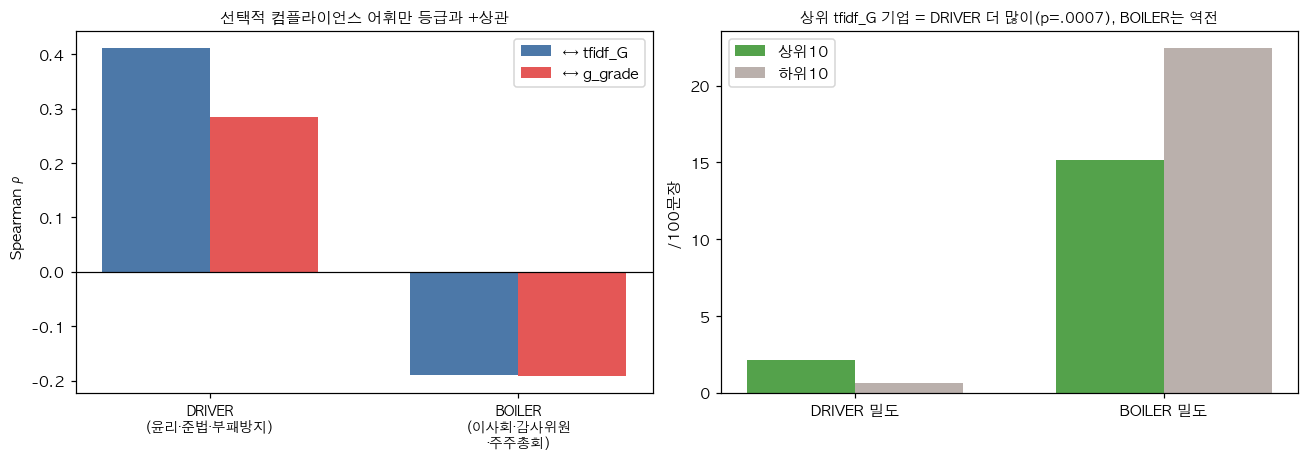

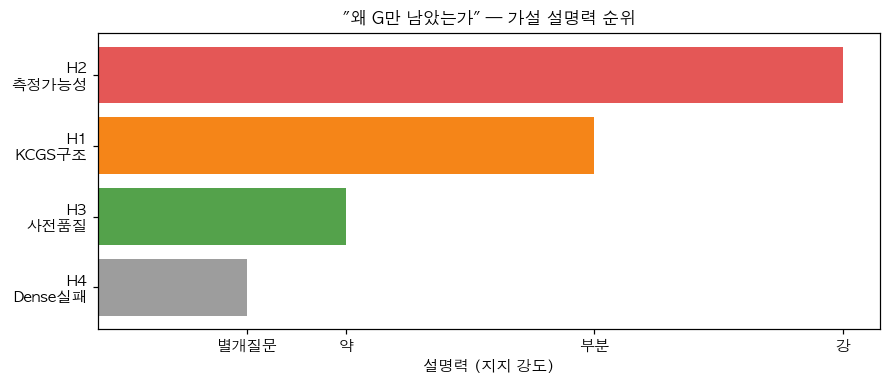

In [24]:
# H2(최종 1위) — G를 끄는 건 이사회가 아니라 '선택적' 컴플라이언스·윤리·부패방지 어휘
dens = pd.read_csv(f"{DP}/08_h2_keyword_density_corr.csv")
print("H2 키워드 밀도 ↔ 점수/등급 (선택적 DRIVER vs 의무 BOILER):")
display(dens)
tb = pd.read_csv(f"{DP}/08_h2_top_vs_bottom.csv")
print("tfidf_G 상위10 vs 하위10 비교(요약):", tb.shape); display(tb.head(8))
show_fig("08_h2_measurability"); show_fig("08_synthesis_ranking")

**해석.** `tfidf_G`를 실제로 끄는 단어는 이사회·사외이사·주주(거의 모든 보고서에 등장 → `max_df`가 제거)가 아니라 **컴플라이언스·윤리·부패방지** 같은 *선택적* 거버넌스 어휘다. 높은 G 기업은 이를 선택적으로 더 공시한다(상>하위 Mann-Whitney p=0.0007). TF-IDF의 IDF 가중이 이 희소·변별 어휘를 분리·증폭하는 반면, dense 임베딩은 보고서마다 비슷한 거버넌스 보일러플레이트에 묻혀 같은 G를 복제하지 못한다(단어·의미가 G에서 정반대). **단, G 신호 자체는 약하다(유의≠중요).**

## 10. 부록 강건성 — LMG/Shapley · 다중검정 보정 · 금융 제외 · 숫자 밀도

**핵심 결론(규모 1차 지배 · seed-G만 강건)이 분석 선택에 흔들리는지 점검한다.** *(논문 부록 A에 대응)* 엔진 `analysis/11_defense_additional.py`, 산출물 `11_defense_*.csv`.

In [25]:
# A1 LMG/Shapley — 투입순서 평균 R² 분해 (순서 의존 제거): 규모 ≈ 분량 > 업종 ≫ 연도
lmg = pd.read_csv(f"{DP}/11_defense_lmg_shapley.csv")
print("LMG/Shapley 투입순서-평균 분해 (통합등급; ols=OLS R², mcf=McFadden):")
display(lmg[["variable","ols_lmg","ols_share","mcf_lmg","mcf_share"]].round(3))
print("→ 투입 순서를 평균해도 규모(≈47%)·분량(≈40%)이 설명력의 대부분. 텍스트는 통제 위 증분.")

LMG/Shapley 투입순서-평균 분해 (통합등급; ols=OLS R², mcf=McFadden):


,variable,ols_lmg,ols_share,mcf_lmg,mcf_share
0,규모,0.236,0.466,0.099,0.490
1,분량,0.201,0.397,0.077,0.381
2,업종,0.069,0.135,0.026,0.127
3,연도,0.001,0.002,0.000,0.001


→ 투입 순서를 평균해도 규모(≈47%)·분량(≈40%)이 설명력의 대부분. 텍스트는 통제 위 증분.


In [26]:
# A2 다중검정 보정 — 완전통제 자기차원 계수 12개에 Bonferroni·BH-FDR
padj = pd.read_csv(f"{DP}/11_defense_table5_p_adjusted.csv")
print("완전통제 자기차원 계수 12개 — 다중검정 보정:")
display(padj[["label","dim","coef","p_raw","p_bonferroni","p_bh_fdr","sig"]].round(4))
print("→ BH-FDR(12검정) 후 생존: seed-G (q=.041). supervised-S 는 q=.078 로 경계(전역보정 시 탈락).")

완전통제 자기차원 계수 12개 — 다중검정 보정:


,label,dim,coef,p_raw,p_bonferroni,p_bh_fdr,sig
0,① seed TF-IDF,E,0.298,0.121,1.000,0.290,NaN
1,① seed TF-IDF,S,0.004,0.983,1.000,0.983,NaN
2,① seed TF-IDF,G,0.378,0.003,0.041,0.041,**
3,② fastText 확장,E,0.235,0.260,1.000,0.519,NaN
4,② fastText 확장,S,0.099,0.574,1.000,0.705,NaN
5,② fastText 확장,G,0.302,0.086,1.000,0.290,NaN
6,③ dense cosine,E,0.255,0.117,1.000,0.290,NaN
7,③ dense cosine,S,0.094,0.559,1.000,0.705,NaN
8,③ dense cosine,G,-0.058,0.693,1.000,0.756,NaN
9,③ dense supervised,E,0.157,0.477,1.000,0.705,NaN


→ BH-FDR(12검정) 후 생존: seed-G (q=.041). supervised-S 는 q=.078 로 경계(전역보정 시 탈락).


In [27]:
# A3 금융·보험 제외 강건성 — 위계적 R² 재계산 (규모 지배가 업종 구성 탓인지)
fin = pd.read_csv(f"{DP}/11_defense_finance_excluded_hierarchical_r2.csv")
print("금융·보험 제외 후 위계적 R²:"); display(fin)
# A4 숫자·단위 밀도(서술 구체성) ↔ 등급 — 탐색적 보조지표
nd = pd.read_csv(f"{DP}/11_defense_number_density_correlations.csv")
print("숫자·단위 밀도 ↔ 등급 상관(탐색):"); display(nd)
# 표본 업종 분포 (대표성 한계 명시)
ind = pd.read_csv(f"{DP}/11_defense_industry_distribution.csv")
print("표본 업종 분포:"); display(ind)

금융·보험 제외 후 위계적 R²:


,block,ols_r2,ols_dr2,mcfadden,mcf_dr2
0,+규모,0.502,0.502,0.183,0.183
1,+분량,0.518,0.016,0.193,0.010
2,+업종,0.555,0.037,0.211,0.019
3,+연도,0.556,0.001,0.213,0.001


숫자·단위 밀도 ↔ 등급 상관(탐색):


,x,y,rho,p
0,numeric_density_per_1k_char,log_assets,-0.106,0.039
1,numeric_density_per_1k_char,esg_grade_num,-0.245,0.000
2,numeric_density_per_1k_char,e_grade,-0.208,0.000
3,numeric_density_per_1k_char,s_grade,-0.264,0.000
4,numeric_density_per_1k_char,g_grade,-0.204,0.000


표본 업종 분포:


,sector,company_years,companies,ratio
0,금융·보험,78,26,0.205
1,유통·물류·건설·기타,66,22,0.173
2,화학·소재,63,21,0.165
3,기계·전자·운송장비,60,20,0.157
4,제약·바이오·의료,42,14,0.110
5,음식료·소비재,36,12,0.094
6,1차금속,18,6,0.047
7,IT·통신·미디어,18,6,0.047


## 11. 한계 · 결론

**사업보고서의 ESG 텍스트는 신호이지만, 순수한 ESG 신호는 아니다.** *(Discussion)*

- **인과 아님**: 통제 관찰연구(연관/예측). 공시 강도와 실제 성과를 구분할 수 없다(cheap-talk 가능) → 기업 "그린워싱" 단정 금지(익명·집계).
- **준거의 한계**: 종속변수 KCGS 등급 자체가 규모에 크게 좌우(규모 단독 43%) → 통제 후 텍스트 약신호가 *텍스트 한계*인지 *준거의 규모편향*인지 본 설계로 분리 불가. **모든 결론은 KCGS 단일 기준의 잠정 결론.**
- **약신호·표현 한정**: 통제 후 텍스트 증분 ≤5%p, 생존 신호도 부분ρ 0.13~0.20·CI 넓음("유의 ≠ 중요"). G 생존은 seed TF-IDF 표현에 한정(단 `max_df` 규칙엔 강건), 전역 다중검정 후엔 seed-G만 생존.
- **표본**: n=381(127사)·3년·단일 평가기관 — 수업용 pilot panel, 검정력 제약. E의 null은 "신호 없음"이 아니라 "이 표본·이 준거에서 탐지 못함".
- **발전 방향**: 복수 평가기관 검증(준거 편향 분리) · 의무화(2026 거버넌스 전면·2028~ 규모별 시차)를 자연실험(staggered DiD)으로 · 수치 밀도(서술 구체성) 지표 · 업종별 이질성.

**결론 (RQ 답):** **RQ1** 통제 전 연관은 실재하나 점수는 규모와 함께 움직인다. **RQ2** 통제 후 텍스트의 추가 설명력은 작다(규모가 1차). **RQ3** 남는 신호의 검출은 표현 방식에 의존한다(seed=G·supervised=S, 과반 재현 없음). 공시는 늘어난다 — 그러나 보완장치가 없으면 그것은 '정보의 질'보다 '형식적 공시 역량 차이'가 늘어날 위험이 있다.

## 12. 재현 · 제출 점검

In [28]:
# 재현·제출 점검 요약
print("=== 재현/제출 점검 ===")
print("· 분석 패널:", m.shape, "| 381 기업-연도 · 결측 0")
print("· 위에서 아래로 실행 시 절 2·6·7(EDA·타당성·회귀)는 라이브 재현, 절 5·8·9·10은 검증 엔진 산출물 정리")
print("· API key: os.environ(.env)에서만 로드 — 노트북·출력에 키 값 없음 ✓  (현재 환경 로드 여부:", bool(os.environ.get("DART_API_KEY")), ")")
print("· 헤드라인: 규모 단독 R² 0.433 · 완전통제 후 seed-G 0.378** · supervised-S 0.550* · 표현별 생존차원 상이(E0/S1/G1)")
print("· 제출물: ① ESG_최종보고서.docx (논문형)  + ② 본 노트북 (.ipynb)")

=== 재현/제출 점검 ===
· 분석 패널: (381, 50) | 381 기업-연도 · 결측 0
· 위에서 아래로 실행 시 절 2·6·7(EDA·타당성·회귀)는 라이브 재현, 절 5·8·9·10은 검증 엔진 산출물 정리
· API key: os.environ(.env)에서만 로드 — 노트북·출력에 키 값 없음 ✓  (현재 환경 로드 여부: False )
· 헤드라인: 규모 단독 R² 0.433 · 완전통제 후 seed-G 0.378** · supervised-S 0.550* · 표현별 생존차원 상이(E0/S1/G1)
· 제출물: ① ESG_최종보고서.docx (논문형)  + ② 본 노트북 (.ipynb)
